# RQ7: Which evaluation metrics (MAE, RMSE, R²) best characterise model performance?

Dataset: Almost Million Songs Dataset (Kaggle)  
Target: Popularity  
Task: Evaluation Metrics Comparison

In [1]:
# ── Imports ─────────────────────────

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries loaded ✅")

Libraries loaded ✅


In [2]:
# ── Load dataset ─────────────────────────

data_path = None

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename.endswith('.csv'):
            data_path = os.path.join(dirname, filename)
            break

df = pd.read_csv(data_path)

print("Shape:", df.shape)
df.head()

Shape: (899702, 16)


,track_id,genres,track_artists,tempo,energy,key,popularity,mode,time_signature,speechiness,danceability,valence,acousticness,liveness,instrumentalness,name
0,07vS8obfeZbr8H4MgQfXR7,"['indie pop', 'la indie', 'pov: indie']",Phoebe Bridgers,97.129,0.123,7.0,0.0,1.0,4.0,0.0407,0.373,0.138,0.9480,0.0816,0.000000,Friday I'm In Love - Recorded at Spotify Studi...
1,1PEqh7awkpuepLBSq8ZwqD,"['lilith', 'new wave pop']",NaN,103.773,0.453,5.0,71.0,1.0,4.0,0.0348,0.744,0.122,0.6270,0.0898,0.421000,I Love You Always Forever
2,7E8pPgBY84oDaXRcqODavR,"['deep groove house', 'house', 'tech house']",NaN,122.030,0.878,9.0,0.0,0.0,4.0,0.0357,0.747,0.897,0.0794,0.3700,0.000531,Love Too Deep - Radio Edit
3,0Atml4huw4Fgyk6YSHiK4M,[],NaN,84.099,0.484,7.0,0.0,1.0,4.0,0.0356,0.604,0.564,0.1000,0.0865,0.000000,No Tiren Las Botellas
4,4WYDmIZrwxBHdBYdvi5oQO,"['chill lounge', 'deep chill']",NaN,156.017,0.447,0.0,7.0,1.0,4.0,0.0613,0.761,0.761,0.0616,0.0822,0.873000,El Momento de Despertar - Blue Sky Mix


In [3]:
# ── Preprocessing ─────────────────────────

TARGET = 'popularity'

drop_cols = [c for c in ['track_id','song_id','title','artist_name','name','id','genres','track_artists'] if c in df.columns]
df = df.drop(columns=drop_cols)

df = df.select_dtypes(include=[np.number])

df = df.dropna(subset=[TARGET])
df = df.fillna(df.median())

# reduce size
if len(df) > 100000:
    df = df.sample(100000, random_state=42).reset_index(drop=True)

FEATURES = [c for c in df.columns if c != TARGET]

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [4]:
# ── Model Training ─────────────────────────

model = RandomForestRegressor(
    n_estimators=60,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

In [5]:
# ── Evaluation Metrics ─────────────────────────

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

metrics_df = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²"],
    "Value": [mae, rmse, r2]
})

display(metrics_df)

,Metric,Value
0,MAE,16.387986
1,RMSE,19.167507
2,R²,0.074727


In [6]:
# ── Table 7.1 ─────────────────────────

styled = metrics_df.style\
    .format({"Value": "{:.3f}"})\
    .set_caption("Table 7.1: Evaluation Metrics for Model Performance (RQ7)")\
    .background_gradient(cmap="Blues", subset=["Value"])\
    .set_properties(**{
        'text-align': 'center',
        'font-size': '11pt'
    })

display(styled)

,Metric,Value
0,MAE,16.388
1,RMSE,19.168
2,R²,0.075


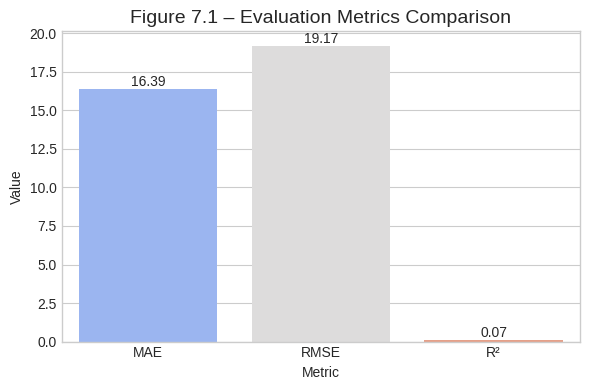

In [7]:
# ── Figure 7.1 ─────────────────────────

plt.figure(figsize=(6,4))

sns.barplot(data=metrics_df, x="Metric", y="Value", palette="coolwarm")

plt.title("Figure 7.1 – Evaluation Metrics Comparison", fontsize=14)

for i, v in enumerate(metrics_df["Value"]):
    plt.text(i, v, f"{v:.2f}", ha='center', va='bottom')

plt.tight_layout()
plt.show()

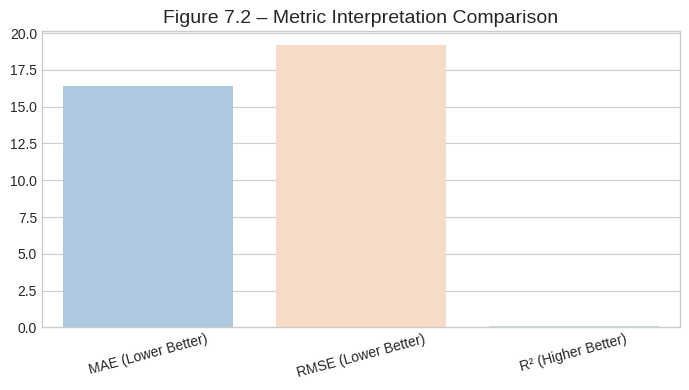

In [8]:
# ── Figure 7.2 ─────────────────────────

labels = ["MAE (Lower Better)", "RMSE (Lower Better)", "R² (Higher Better)"]
values = [mae, rmse, r2]

plt.figure(figsize=(7,4))

sns.barplot(x=labels, y=values, palette=["#A7C7E7", "#FFDAC1", "#B5EAD7"])

plt.title("Figure 7.2 – Metric Interpretation Comparison", fontsize=14)
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

In [9]:
# ── Conclusion ─────────────────────────

print("Conclusion:")

print("MAE provides a simple and interpretable measure of error.")
print("RMSE penalises large errors more strongly.")
print("R² indicates how well the model explains variance in the data.")

print("Together, these metrics provide a comprehensive evaluation of model performance.")

Conclusion:
MAE provides a simple and interpretable measure of error.
RMSE penalises large errors more strongly.
R² indicates how well the model explains variance in the data.
Together, these metrics provide a comprehensive evaluation of model performance.
